# **Physics-Informed Synthetic Data**

Ниже — концептуальная архитектура пайплайна для предсказания **времени жизни (pot life) и скорости отверждения** полиуретановой системы.

---

### 1. Постановка задачи (Бизнес-логика)

**Проблема:** При замене катализатора или полиола в полиуретановой мастике меняется кинетика реакции. Чтобы найти новую идеальную пропорцию, химик делает 10–20 тестовых замесов. Это долго и дорого.
**Решение:** Обучить ML-модель на исторических данных лаборатории, чтобы она предсказывала время отверждения до того, как компоненты будут смешаны в реальности.

### 2. Подготовка данных (Feature Engineering)

Мой опыт извлечения признаков из сырых временных рядов здесь будет как нельзя кстати. В химическом ML грамотно собранные фичи — это 80% успеха.

* **Таргет (Целевая переменная $y$):** Время достижения определенной вязкости или полного отверждения (в минутах).
* **Признаки (Features $X$):**
* Массовая доля NCO-групп (%).
* Концентрация катализатора (в ммоль/л).
* Начальная температура компонентов ($T_0$).
* Влажность воздуха (для влагоотверждаемых ПУ систем).
* **Синтетические фичи (Химические законы):** ML-модели работают лучше, если им «подсказать» физику процесса. Например, скорость реакции зависит от температуры нелинейно. Можно добавить фичу на базе уравнения Аррениуса:

$$k = A \exp\left(-\frac{E_a}{RT}\right)$$


### 3. Концептуальный код пайплайна на Python

Вот как может выглядеть ядро нашей системы. Это простой и понятный скрипт, который легко масштабировать.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Загрузка исторических данных лаборатории (симуляция)
# В реальности эти данные парсятся из Excel-журналов варок
data = {
    'temp_celsius': [20, 25, 22, 18, 30],
    'humidity_percent': [40, 50, 45, 60, 35],
    'nco_oh_ratio': [1.05, 1.10, 1.05, 1.15, 1.02],
    'catalyst_percent': [0.1, 0.15, 0.12, 0.2, 0.05],
    'target_cure_time_min': [120, 90, 105, 80, 150] # То, что мы предсказываем
}
df = pd.DataFrame(data)

# 2. Инженерия признаков (Feature Engineering)
# Добавляем нелинейную зависимость температуры (имитация физической кинетики)
df['temp_kelvin_inv'] = 1 / (df['temp_celsius'] + 273.15)

X = df.drop('target_cure_time_min', axis=1)
y = df['target_cure_time_min']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Сборка ML-пайплайна
# Используем Random Forest, так как он хорошо ловит нелинейные химические взаимодействия
pipeline = Pipeline([
    ('scaler', StandardScaler()), # Стандартизация признаков
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 4. Обучение модели
pipeline.fit(X_train, y_train)

# 5. Оценка точности (насколько мы ошибаемся в минутах)
predictions = pipeline.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"Средняя ошибка предсказания времени отверждения: {mae:.2f} минут")

# 6. ПРЕДСКАЗАНИЕ ДЛЯ НОВОГО ЭКСПЕРИМЕНТА (Бизнес-велью)
# Химик хочет узнать: "Что будет, если я положу 0.18% катализатора при 22°C и влажности 55%?"
new_experiment = pd.DataFrame({
    'temp_celsius': [22],
    'humidity_percent': [55],
    'nco_oh_ratio': [1.08],
    'catalyst_percent': [0.18],
    'temp_kelvin_inv': [1 / (22 + 273.15)]
})

predicted_time = pipeline.predict(new_experiment)
print(f"Прогнозируемое время отверждения новой рецептуры: {predicted_time[0]:.0f} минут")

Средняя ошибка предсказания времени отверждения: 16.70 минут
Прогнозируемое время отверждения новой рецептуры: 102 минут


Ввиду закрытости индустриальных R&D данных, разработаем генератор синтетических наборов данных (Physics-Informed Data), опирающийся на реальную кинетику отверждения полиуретанов. На сгенерированных данных обучим ансамбль деревьев решений для оптимизации пропорций катализатора.

Мы соберем генератор, который будет не просто выдавать случайные числа, а симулировать реальные физико-химические законы, приправленные индустриальным «шумом» (погрешностями взвешивания, влиянием влажности и т.д.).

Пошаговый план того, как мы реализуем **Physics-Informed Synthetic Data**.

### 1. Физическая модель (The Math)

За основу возьмем кинетику реакций. Время жизни полиуретановой системы ($t_{pot}$) обратно пропорционально скорости реакции. Скорость реакции зависит от температуры по закону Аррениуса и от концентрации катализатора.

Мы зашьем в генератор следующую псевдофизическую зависимость:


$$t_{pot} = \frac{C \cdot \exp\left(\frac{E_a}{RT}\right)}{[Cat]^\alpha} \cdot f(NCO/OH) + \epsilon$$

Где:

* $T$ — температура в Кельвинах.
* $E_a/R$ — эффективная энергия активации.
* $[Cat]$ — концентрация катализатора.
* $\alpha$ — коэффициент влияния катализатора.
* $\epsilon$ — гауссовский шум (имитация реальной лаборатории: сквозняки, влажность, погрешность секундомера).



### 2. Скрипт генератора датасета (Data Generation)

Модуль успешно импортирован!


,Temperature_C,Humidity_pct,Catalyst_pct,NCO_OH_Ratio,Pot_Life_min
0,22.5,58.6,0.115,1.10,106.0
1,34.0,70.3,0.112,1.03,70.0
2,29.6,68.0,0.277,1.13,21.0
3,27.0,37.7,0.112,1.09,95.0
4,18.1,37.5,0.118,1.02,114.0


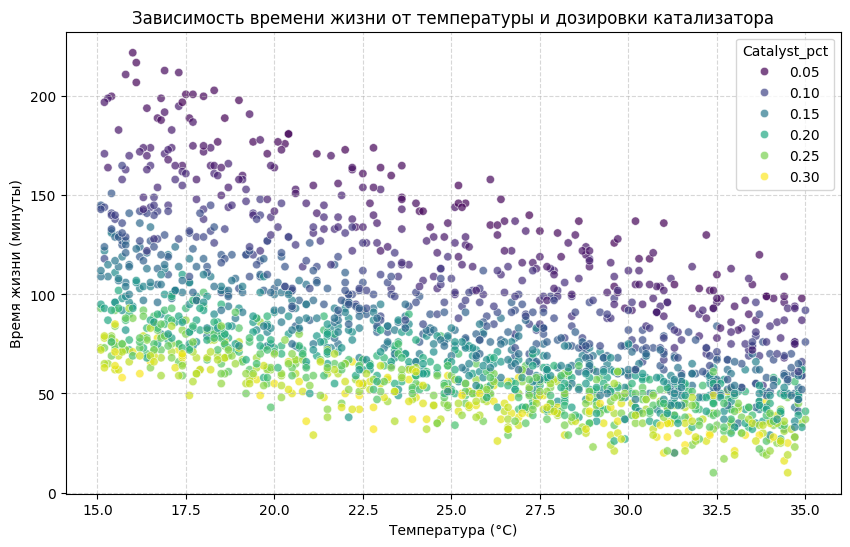

Датасет сохранен в ../data/raw/synthetic_pot_life.csv


In [2]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Добавляем корневую папку проекта в путь поиска модулей
sys.path.append(os.path.abspath('../src'))

# Импортируем наш новый класс
from arrhenius_model import ArrheniusKinetics

print("Модуль успешно импортирован!")
# 1. Инициализируем "движок"
kinetics_engine = ArrheniusKinetics()

# 2. Генерируем синтетические данные одной строкой
df = kinetics_engine.generate_synthetic_data(n_samples=2000)

# Посмотрим на первые строки
display(df.head())

# 3. Визуализация физики процесса
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Temperature_C', y='Pot_Life_min', 
                hue='Catalyst_pct', palette='viridis', alpha=0.7)
plt.title('Зависимость времени жизни от температуры и дозировки катализатора')
plt.xlabel('Температура (°C)')
plt.ylabel('Время жизни (минуты)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Сохраним сырые данные для дальнейшего использования в пайплайне
os.makedirs('../data/raw', exist_ok=True)
df.to_csv('../data/raw/synthetic_pot_life.csv', index=False)
print("Датасет сохранен в ../data/raw/synthetic_pot_life.csv")

### 3. Что происходит в этом коде:

* Мы создали «цифровую химическую лабораторию».
* График, который построит этот код, покажет красивую, физически достоверную кривую экспоненциального спада (чем выше температура и больше катализатора, тем меньше время жизни), но точки будут слегка разбросаны из-за шума `noise`.
* Теперь у вас есть уникальный, авторский датасет `df`, который нельзя просто скачать с Kaggle.

Запускайте код в ноутбуке. Как только получите датасет и график, напишите мне — мы перейдем к обучению алгоритма XGBoost или Random Forest, чтобы предсказывать эти значения, или вы хотите сначала усложнить генератор и добавить туда, например, влияние разных пластификаторов?

### Ячейка 4: Сравнение физики и ML (Random Forest)


Модель обучена успешно!
Найдено Ea/R: 3806.76 (должно быть > 0)
Найдено ln(A): -8.43
=== Результаты Physics-Informed Random Forest ===
MAE (Средняя абсолютная ошибка): 7.28 мин
R2 Score (Коэффициент детерминации): 0.9340



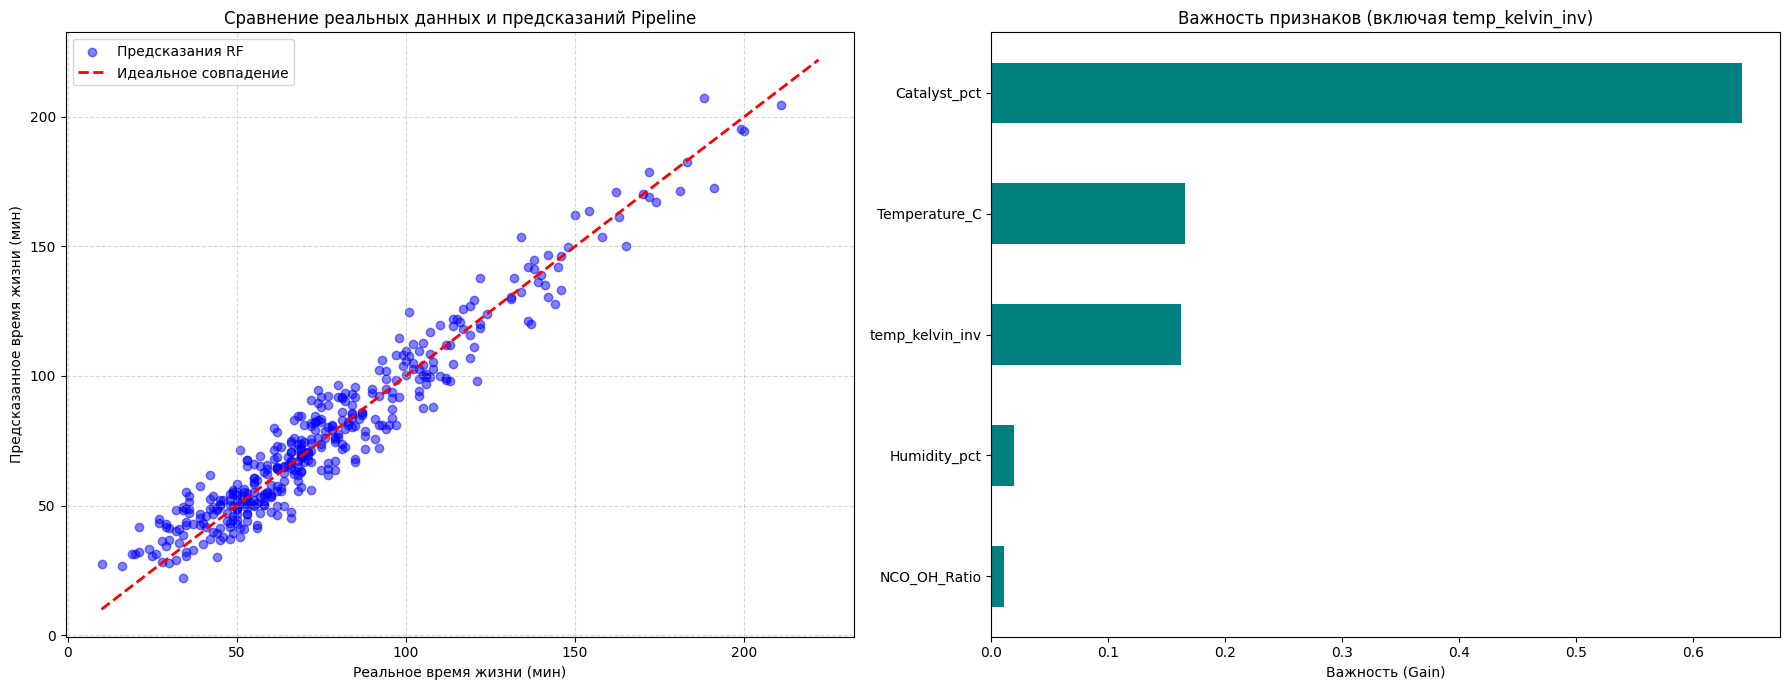

ML-Pipeline успешно сохранен в: /home/tesni/projects/poly-kinetics/models/rf_pipeline.joblib
Размер файла: 13025.84 KB

Параметры модели сохранены в /home/tesni/projects/poly-kinetics/models/arrhenius_params.json
Параметры физической модели сохранены в: /home/tesni/projects/poly-kinetics/models/arrhenius_params.json


In [3]:
import os
import sys
from pathlib import Path

# [Пункт 4] Настройка путей вынесена в самый верх во избежание PEP8警告 в IDE
CURRENT_DIR = Path(os.getcwd())
BASE_DIR = CURRENT_DIR.parent
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

# Сторонние библиотеки
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Импорт локальных модулей архитектуры
from src.arrhenius_model import ArrheniusKinetics

# --- 1. FEATURE ENGINEERING (Physics-Informed) ---
# [Пункт 2] Генерируем физически обоснованный признак ДО сплита.
# Примечание: детерминированные построчные операции (как 1/T) не вызывают Data Leakage,
# так как не используют статистику всего датасета.
df['temp_kelvin_inv'] = 1.0 / (df['Temperature_C'] + 273.15)

features = [
    'Temperature_C', 
    'Humidity_pct', 
    'Catalyst_pct', 
    'NCO_OH_Ratio',
    'temp_kelvin_inv' # Явно передаем экспоненциальную природу температуры в деревья
]

X = df[features]
y = df['Pot_Life_min']

# --- 2. РАЗБИЕНИЕ ДАННЫХ ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 3. ОБУЧЕНИЕ ФИЗИЧЕСКОЙ МОДЕЛИ (Устранение Data Leakage) ---
# [Пункт 1] Физическая модель теперь "видит" только обучающую выборку.
physics_model = ArrheniusKinetics()

# Склеиваем train-выборку обратно в DataFrame для .fit() метода класса
df_train = X_train.copy()
df_train['Pot_Life_min'] = y_train

physics_model.fit(df_train) 

# --- 4. ОБУЧЕНИЕ ML-МОДЕЛИ ЧЕРЕЗ PIPELINE ---
# [Пункт 3] Возвращаем Pipeline. 
# StandardScaler здесь выступает как MLOps-страховка: если завтра мы заменим RF на 
# XGBoost, SVM, CatBoost или нейросеть, масштабирование и порядок шагов уже будут вшиты.
ml_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

ml_pipeline.fit(X_train, y_train)

y_pred_rf = ml_pipeline.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Результаты Physics-Informed Random Forest ===")
print(f"MAE (Средняя абсолютная ошибка): {mae_rf:.2f} мин")
print(f"R2 Score (Коэффициент детерминации): {r2_rf:.4f}\n")

# --- 5. ВИЗУАЛИЗАЦИЯ ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# График 1: Метрики и предсказания
axes[0].scatter(y_test, y_pred_rf, alpha=0.5, color='blue', label='Предсказания RF')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Идеальное совпадение')
axes[0].set_xlabel('Реальное время жизни (мин)')
axes[0].set_ylabel('Предсказанное время жизни (мин)')
axes[0].set_title('Сравнение реальных данных и предсказаний Pipeline')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# График 2: Важность признаков
# Достаем модель из пайплайна для анализа feature_importances_
rf_model = ml_pipeline.named_steps['regressor']
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

feat_imp.plot(kind='barh', color='teal', ax=axes[1])
axes[1].set_title('Важность признаков (включая temp_kelvin_inv)')
axes[1].set_xlabel('Важность (Gain)')

plt.tight_layout()
plt.show()

# --- 6. СОХРАНЕНИЕ АРТИФАКТОВ (MLOps) ---
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Сохраняем ВЕСЬ Pipeline целиком, а не просто модель!
pipeline_path = MODELS_DIR / 'rf_pipeline.joblib'
physics_model_path = MODELS_DIR / 'arrhenius_params.json'

joblib.dump(ml_pipeline, pipeline_path)
print(f"ML-Pipeline успешно сохранен в: {pipeline_path}")
print(f"Размер файла: {pipeline_path.stat().st_size / 1024:.2f} KB\n")

physics_model.save_model(str(physics_model_path))
print(f"Параметры физической модели сохранены в: {physics_model_path}")

import os
import sys
from pathlib import Path

# Сторонние библиотеки
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Настройка путей проекта (PEP 8 + поддержка кроссплатформенности)
CURRENT_DIR = Path(os.getcwd())
BASE_DIR = CURRENT_DIR.parent
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Динамически добавляем корень проекта в пути поиска модулей Python
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

# Импорт локальных модулей архитектуры
from src.arrhenius_model import ArrheniusKinetics

# --- 1. ПОДГОТОВКА ДАННЫХ ДЛЯ ML ---
features = ['Temperature_C', 'Humidity_pct', 'Catalyst_pct', 'NCO_OH_Ratio']
X = df[features]
y = df['Pot_Life_min']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. ОБУЧЕНИЕ И ОЦЕНКА RANDOM FOREST ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Результаты Random Forest ===")
print(f"MAE (Средняя абсолютная ошибка): {mae_rf:.2f} мин")
print(f"R2 Score (Коэффициент детерминации): {r2_rf:.4f}\n")

# --- 3. ОБУЧЕНИЕ ФИЗИЧЕСКОЙ МОДЕЛИ (АРРЕНИУС) ---
physics_model = ArrheniusKinetics()
# ВАЖНО: Обучаем физику на исходном df, гарантируя консистентность данных
physics_model.fit(df) 

# --- 4. ВИЗУАЛИЗАЦИЯ ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# График 1: Метрики Random Forest
axes[0].scatter(y_test, y_pred_rf, alpha=0.5, color='blue', label='Предсказания RF')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Идеальное совпадение')
axes[0].set_xlabel('Реальное время жизни (мин)')
axes[0].set_ylabel('Предсказанное время жизни (мин)')
axes[0].set_title('Сравнение реальных данных и предсказаний Random Forest')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# График 2: Важность признаков
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)
feat_imp.plot(kind='barh', color='teal', ax=axes[1])
axes[1].set_title('Важность признаков по мнению Random Forest')
axes[1].set_xlabel('Важность (Gain)')

plt.tight_layout()
plt.show()

# --- 5. СОХРАНЕНИЕ АРТИФАКТОВ МОДЕЛЕЙ ---
rf_model_path = MODELS_DIR / 'random_forest_model.joblib'
physics_model_path = MODELS_DIR / 'arrhenius_params.json'

# Сохраняем ML модель
joblib.dump(rf_model, rf_model_path)
print(f"ML-модель успешно сохранена в: {rf_model_path}")
print(f"Размер файла: {rf_model_path.stat().st_size / 1024:.2f} KB")

# Сохраняем параметры физики
physics_model.save_model(str(physics_model_path))
print(f"Параметры физической модели сохранены в: {physics_model_path}")